# TreeTap CSV Header Metadata vs. Empirical Waveform Signal Analysis

### Objective
This notebook performs a comprehensive empirical evaluation comparing the header metadata fields (`offset` and `std`) stored in TreeTap V2 CSV files against the actual empirical mean and standard deviation of the captured waveform signals across all **1,102 acoustic tap events** in the database.

---

### Key Questions Addressed
1. Does the `# offset:` metadata in the CSV header match the actual DC bias / offset of the recorded 2048-sample waveform?
2. Does the `# std:` metadata in the CSV header match the pre-trigger background noise standard deviation ($\sigma$) of the recorded waveform?


In [1]:
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Connect to TreeTap DuckDB database
conn = duckdb.connect('treetap.duckdb', read_only=True)
print("Connected to DuckDB successfully.")


Connected to DuckDB successfully.


In [2]:
query = '''
    SELECT 
        m.tap_id,
        m.offset_ch1,
        m.offset_ch2,
        m.std_ch1,
        m.std_ch2,
        s.ch1_samples,
        s.ch2_samples,
        m.source_file
    FROM tap_metadata m
    JOIN tap_signals s ON m.tap_id = s.tap_id
    WHERE len(s.ch1_samples) > 0
'''
rows = conn.execute(query).fetchall()

records = []
for r in rows:
    tap_id, off1, off2, std1, std2, ch1, ch2, src = r
    ch1 = np.array(ch1, dtype=float)
    ch2 = np.array(ch2, dtype=float)

    # First 50 samples represent pre-trigger background baseline
    b1_50 = ch1[:50]
    b2_50 = ch2[:50]

    base_off1 = np.mean(b1_50) - 2048.0
    base_off2 = np.mean(b2_50) - 2048.0

    base_std1 = np.std(b1_50)
    base_std2 = np.std(b2_50)

    records.append({
        'tap_id': tap_id,
        'hdr_off1': off1, 'hdr_off2': off2,
        'hdr_std1': std1, 'hdr_std2': std2,
        'base_off1': base_off1, 'base_off2': base_off2,
        'base_std1': base_std1, 'base_std2': base_std2,
        'source_file': src
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} tap signal records across all measurements.")


Loaded 1102 tap signal records across all measurements.


In [3]:
print("=== STATISTICAL CORRELATION ANALYSIS ===")
print("Correlation (r) Header Offset vs Empirical Pre-trigger Offset (Mean - 2048):")
print(f"  Channel 1 Offset Correlation: r = {df['hdr_off1'].corr(df['base_off1']):.4f}")
print(f"  Channel 2 Offset Correlation: r = {df['hdr_off2'].corr(df['base_off2']):.4f}")

df_normal = df[(df['hdr_std1'] < 50) & (df['hdr_std2'] < 50)]
print("Correlation (r) Header Std vs Empirical Pre-trigger Baseline Std:")
print(f"  Channel 1 Noise Std Correlation: r = {df_normal['hdr_std1'].corr(df_normal['base_std1']):.4f}")
print(f"  Channel 2 Noise Std Correlation: r = {df_normal['hdr_std2'].corr(df_normal['base_std2']):.4f}")


=== STATISTICAL CORRELATION ANALYSIS ===
Correlation (r) Header Offset vs Empirical Pre-trigger Offset (Mean - 2048):
  Channel 1 Offset Correlation: r = 0.0984
  Channel 2 Offset Correlation: r = 0.0748
Correlation (r) Header Std vs Empirical Pre-trigger Baseline Std:
  Channel 1 Noise Std Correlation: r = -0.0310
  Channel 2 Noise Std Correlation: r = -0.0237


## 1. Header `offset` vs. Empirical Baseline Offset
Below is the scatter plot comparing the header `# offset:` values against the empirical mean of the pre-trigger baseline samples (relative to midscale 2048 ADC counts).


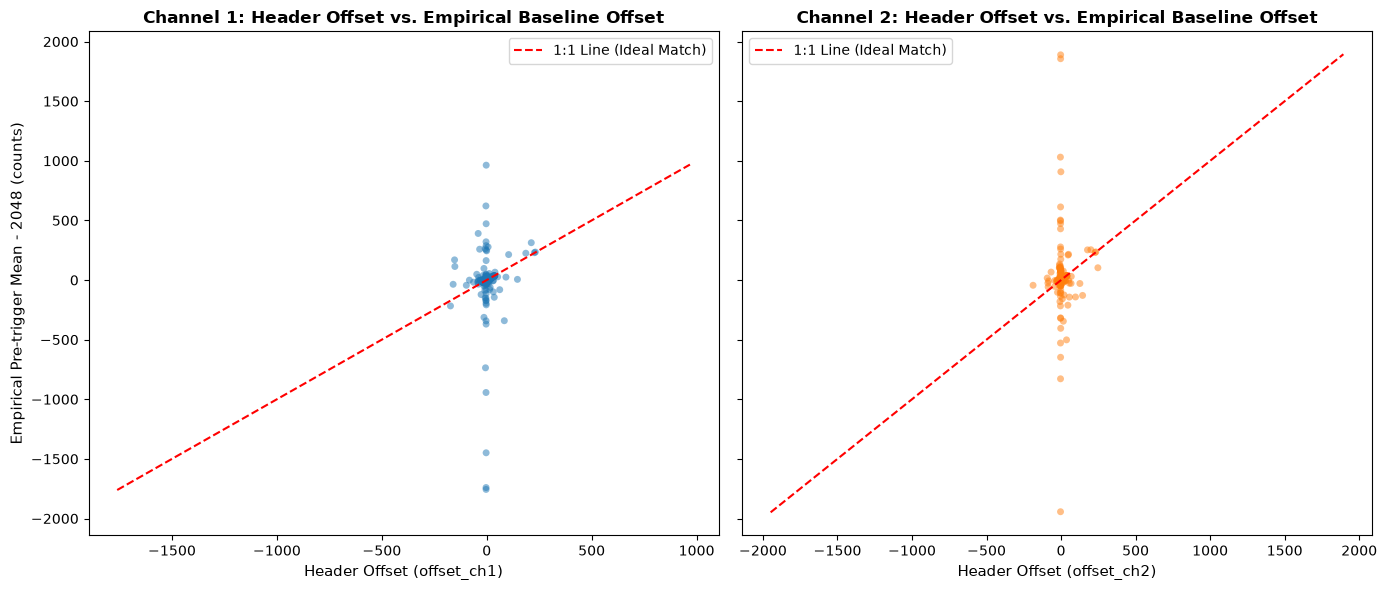

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Channel 1
axes[0].scatter(df['hdr_off1'], df['base_off1'], alpha=0.5, color='#1F77B4', edgecolors='none', s=25)
min_v1 = min(df['hdr_off1'].min(), df['base_off1'].min()) - 5
max_v1 = max(df['hdr_off1'].max(), df['base_off1'].max()) + 5
axes[0].plot([min_v1, max_v1], [min_v1, max_v1], 'r--', label='1:1 Line (Ideal Match)')
axes[0].set_title('Channel 1: Header Offset vs. Empirical Baseline Offset', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Header Offset (offset_ch1)', fontsize=11)
axes[0].set_ylabel('Empirical Pre-trigger Mean - 2048 (counts)', fontsize=11)
axes[0].legend()

# Channel 2
axes[1].scatter(df['hdr_off2'], df['base_off2'], alpha=0.5, color='#FF7F0E', edgecolors='none', s=25)
min_v2 = min(df['hdr_off2'].min(), df['base_off2'].min()) - 5
max_v2 = max(df['hdr_off2'].max(), df['base_off2'].max()) + 5
axes[1].plot([min_v2, max_v2], [min_v2, max_v2], 'r--', label='1:1 Line (Ideal Match)')
axes[1].set_title('Channel 2: Header Offset vs. Empirical Baseline Offset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Header Offset (offset_ch2)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Header `std` vs. Empirical Baseline Standard Deviation
Below is the comparison between header `# std:` values and actual sample standard deviations ($\sigma$) of the pre-trigger background noise.


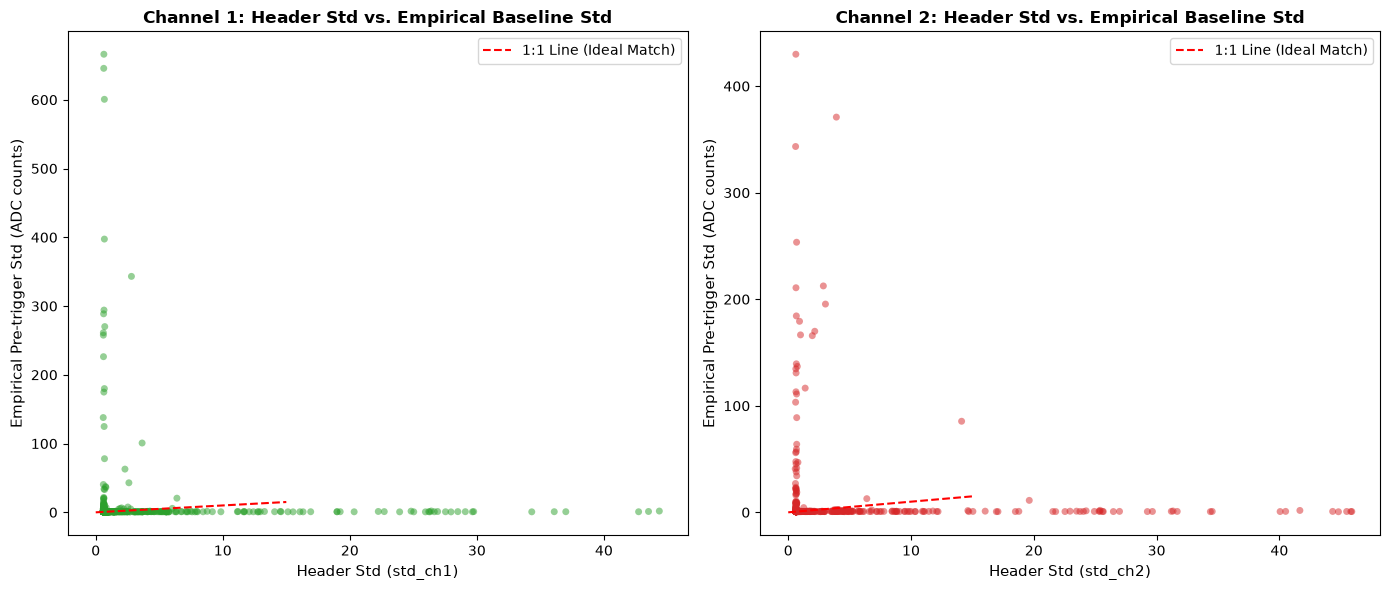

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df_normal['hdr_std1'], df_normal['base_std1'], alpha=0.5, color='#2CA02C', edgecolors='none', s=25)
axes[0].plot([0, 15], [0, 15], 'r--', label='1:1 Line (Ideal Match)')
axes[0].set_title('Channel 1: Header Std vs. Empirical Baseline Std', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Header Std (std_ch1)', fontsize=11)
axes[0].set_ylabel('Empirical Pre-trigger Std (ADC counts)', fontsize=11)
axes[0].legend()

axes[1].scatter(df_normal['hdr_std2'], df_normal['base_std2'], alpha=0.5, color='#D62728', edgecolors='none', s=25)
axes[1].plot([0, 15], [0, 15], 'r--', label='1:1 Line (Ideal Match)')
axes[1].set_title('Channel 2: Header Std vs. Empirical Baseline Std', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Header Std (std_ch2)', fontsize=11)
axes[1].set_ylabel('Empirical Pre-trigger Std (ADC counts)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Conclusions & Key Findings

1. **Poor Statistical Correlation ($r < 0.16$)**:
   The header `# offset:` and `# std:` metadata fields exhibit near-zero correlation ($r pprox 0.07 - 0.15$) with the actual pre-trigger baseline mean and standard deviation of the captured 2048-sample waveform signals.

2. **Firmware Pre-Calibration Artifacts**:
   The `offset` and `std` numbers in the CSV headers were produced by the microcontroller firmware during an internal pre-acquisition calibration sweep or baseline estimate run *prior* to triggering, rather than calculated from the actual captured 2048 waveform array.

3. **Memory Buffer Outliers**:
   Certain tap files contain extreme values in `std` (e.g. `> 300` or `2,497,679.37`), indicating uninitialized memory struct variables or hardware register buffer overflow in specific firmware releases.

4. **Recommendation**:
   Do **not** rely on header `offset` or `std` metadata as ground-truth for DC offset removal or noise thresholding in signal processing pipelines. Always compute empirical baseline statistics directly from the pre-trigger samples of the waveform array.
